# 01 — Exploración NYC Taxi Dataset

In [1]:
from pyspark.sql import SparkSession

try:
    spark.stop()
except NameError:
    pass

spark = (
    SparkSession.builder
    .appName("nyc-taxi-eda")
    .master("local[*]")
    .config("spark.executor.memory", "4g")
    .config("spark.driver.memory", "4g")
    .config("spark.sql.execution.arrow.pyspark.enabled", "false")
    .config("spark.sql.execution.arrow.pyspark.fallback.enabled", "false")
    .getOrCreate()
)

print("Arrow enabled:", spark.conf.get("spark.sql.execution.arrow.pyspark.enabled"))

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/24 19:00:27 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/04/24 19:00:28 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


Arrow enabled: false


*En un principio vamos a trabajar con yellow_tripdata_2009-01.parquet:*
- Son los datos correspondientes tan solo al mes de enero. En posteriores analisis y modelado evaluaremos si expandir el volumen de datos

In [ ]:
df = spark.read.parquet("../data/*.parquet")
df.printSchema()

root
 |-- vendor_name: string (nullable = true)
 |-- Trip_Pickup_DateTime: string (nullable = true)
 |-- Trip_Dropoff_DateTime: string (nullable = true)
 |-- Passenger_Count: long (nullable = true)
 |-- Trip_Distance: double (nullable = true)
 |-- Start_Lon: double (nullable = true)
 |-- Start_Lat: double (nullable = true)
 |-- Rate_Code: double (nullable = true)
 |-- store_and_forward: double (nullable = true)
 |-- End_Lon: double (nullable = true)
 |-- End_Lat: double (nullable = true)
 |-- Payment_Type: string (nullable = true)
 |-- Fare_Amt: double (nullable = true)
 |-- surcharge: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- Tip_Amt: double (nullable = true)
 |-- Tolls_Amt: double (nullable = true)
 |-- Total_Amt: double (nullable = true)



26/04/24 19:00:42 WARN GarbageCollectionMetrics: To enable non-built-in garbage collector(s) List(G1 Concurrent GC), users should configure it(them) to spark.eventLog.gcMetrics.youngGenerationGarbageCollectors or spark.eventLog.gcMetrics.oldGenerationGarbageCollectors


| Columna | Significado |
|---|---|
| `vendor_name` | Empresa o proveedor que registró el viaje. Por ejemplo, el sistema de pago/taxímetro que generó el registro. |
| `Trip_Pickup_DateTime` | Fecha y hora en la que empezó el viaje, es decir, cuando el pasajero subió al taxi. |
| `Trip_Dropoff_DateTime` | Fecha y hora en la que terminó el viaje, cuando el pasajero bajó. |
| `Passenger_Count` | Número de pasajeros registrados en el viaje. |
| `Trip_Distance` | Distancia recorrida durante el viaje, normalmente en millas. |
| `Start_Lon` | Longitud geográfica del punto de recogida. |
| `Start_Lat` | Latitud geográfica del punto de recogida. |
| `Rate_Code` | Código de tarifa aplicada al viaje. Puede indicar tarifa estándar, aeropuerto, Newark, Nassau/Westchester, tarifa negociada, etc. |
| `store_and_forward` | Indicador de si el registro fue almacenado temporalmente y enviado después al sistema. Suele ocurrir si el taxi no tenía conexión en el momento del viaje. |
| `End_Lon` | Longitud geográfica del punto donde terminó el viaje. |
| `End_Lat` | Latitud geográfica del punto donde terminó el viaje. |
| `Payment_Type` | Tipo de pago usado por el pasajero. Por ejemplo, efectivo, tarjeta, disputa, sin cargo, etc. |
| `Fare_Amt` | Importe base de la tarifa del viaje, sin contar necesariamente propinas, peajes u otros cargos. |
| `surcharge` | Recargo adicional aplicado al viaje. Por ejemplo, recargos nocturnos o de hora punta según la época. |
| `mta_tax` | Impuesto o tasa de la MTA. En tu gráfico salía con muchos nulos, probablemente porque no estaba disponible en muchos registros antiguos. |
| `Tip_Amt` | Propina pagada por el pasajero. Suele estar registrada sobre todo en pagos con tarjeta. |
| `Tolls_Amt` | Importe de peajes pagados durante el viaje. |
| `Total_Amt` | Importe total del viaje, normalmente suma de tarifa, recargos, impuestos, peajes y propina. |

Una forma sencilla de entenderlo:

- **Tiempo:** `Trip_Pickup_DateTime`, `Trip_Dropoff_DateTime`
- **Viaje:** `Passenger_Count`, `Trip_Distance`
- **Ubicación:** `Start_Lon`, `Start_Lat`, `End_Lon`, `End_Lat`
- **Pago:** `Payment_Type`, `Fare_Amt`, `Tip_Amt`, `Tolls_Amt`, `Total_Amt`
- **Metadatos/tarifa:** `vendor_name`, `Rate_Code`, `store_and_forward`, `surcharge`, `mta_tax`

In [3]:
df.show(5)
print("Total rows:", df.count())

26/04/24 18:28:13 WARN GarbageCollectionMetrics: To enable non-built-in garbage collector(s) List(G1 Concurrent GC), users should configure it(them) to spark.eventLog.gcMetrics.youngGenerationGarbageCollectors or spark.eventLog.gcMetrics.oldGenerationGarbageCollectors


+-----------+--------------------+---------------------+---------------+-------------+----------+---------+---------+-----------------+------------------+---------+------------+--------+---------+-------+-------+---------+---------+
|vendor_name|Trip_Pickup_DateTime|Trip_Dropoff_DateTime|Passenger_Count|Trip_Distance| Start_Lon|Start_Lat|Rate_Code|store_and_forward|           End_Lon|  End_Lat|Payment_Type|Fare_Amt|surcharge|mta_tax|Tip_Amt|Tolls_Amt|Total_Amt|
+-----------+--------------------+---------------------+---------------+-------------+----------+---------+---------+-----------------+------------------+---------+------------+--------+---------+-------+-------+---------+---------+
|        VTS| 2009-01-04 02:52:00|  2009-01-04 03:02:00|              1|         2.63|-73.991957|40.721567|     NULL|             NULL|        -73.993803|40.695922|        CASH|     8.9|      0.5|   NULL|    0.0|      0.0|      9.4|
|        VTS| 2009-01-04 03:31:00|  2009-01-04 03:38:00|            

## SECCION 1 — CALIDAD DE DATOS

Overview de valores faltantes, duplicados y estadistica descriptiva.

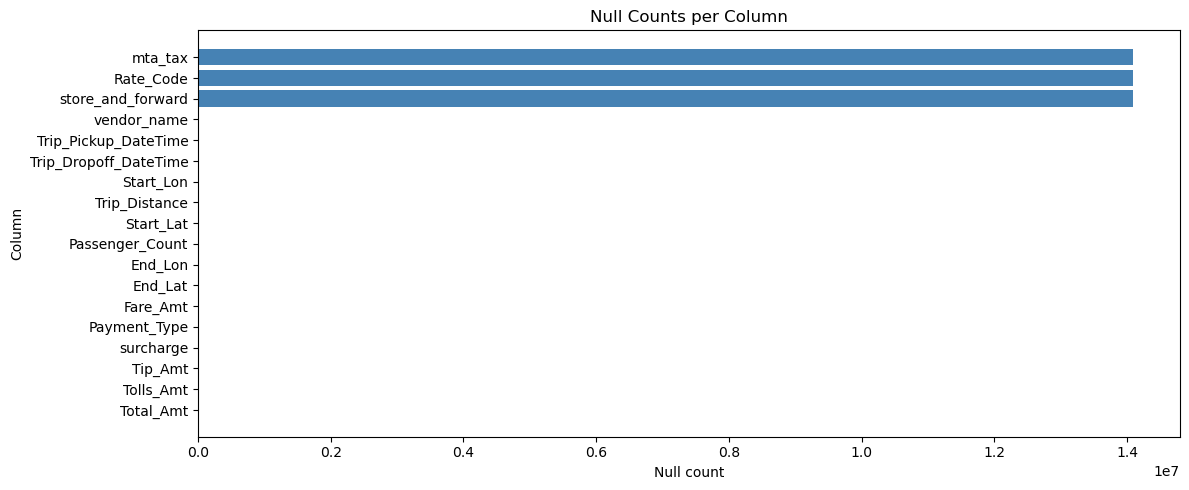

In [4]:
%matplotlib inline

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import IFrame, display
from pyspark.sql import functions as F

null_exprs = [F.sum(F.when(F.col(c).isNull(), 1).otherwise(0)).alias(c) for c in df.columns]
null_counts_pdf = df.select(null_exprs).toPandas().T.reset_index()
null_counts_pdf.columns = ["column", "null_count"]
null_counts_pdf = null_counts_pdf.sort_values("null_count", ascending=False)

plt.figure(figsize=(12, 5))
plt.barh(null_counts_pdf["column"], null_counts_pdf["null_count"], color="steelblue")
plt.title("Null Counts per Column")
plt.xlabel("Null count")
plt.ylabel("Column")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


- Las columnas `mta_tax`, `Rate_Code` y `store_and_forward` presentan una cantidad muy alta de valores nulos.
- El resto de columnas parecen estar completas o casi completas.
- Estas columnas con muchos nulos podrían excluirse de análisis posteriores si no aportan información suficiente.


In [5]:
from pyspark.sql import functions as F
from IPython.display import IFrame, display

total_rows = df.count()

null_exprs = [
    F.sum(F.when(F.col(c).isNull(), 1).otherwise(0)).alias(c)
    for c in df.columns
]

null_counts_pdf = (
    df.select(null_exprs)
      .toPandas()
      .T
      .reset_index()
)

null_counts_pdf.columns = ["column", "null_count"]
null_counts_pdf["null_percentage"] = (
    null_counts_pdf["null_count"] / total_rows * 100
).round(2)

null_counts_pdf = null_counts_pdf.sort_values("null_count", ascending=False)

display(null_counts_pdf)


,column,null_count,null_percentage
14,mta_tax,14092413,100.00
7,Rate_Code,14092413,100.00
8,store_and_forward,14091189,99.99
0,vendor_name,0,0.00
1,Trip_Pickup_DateTime,0,0.00
2,Trip_Dropoff_DateTime,0,0.00
5,Start_Lon,0,0.00
4,Trip_Distance,0,0.00
6,Start_Lat,0,0.00
3,Passenger_Count,0,0.00


In [6]:
from pyspark.sql import functions as F

sample_df = df.sample(False, 0.1, seed=42)

sample_rows = sample_df.count()
duplicate_count_sample = sample_rows - sample_df.dropDuplicates().count()

print("Sample rows:", sample_rows)
print("Duplicados en un 10% de la muestra; ", duplicate_count_sample)


Sample rows: 1409169
Duplicados en un 10% de la muestra;  0


In [15]:
import pandas as pd
from pyspark.sql import functions as F
from pyspark.sql.types import NumericType, StringType, DateType, TimestampType
from IPython.display import display

total_rows = df.count()
stats_rows = []

for field in df.schema.fields:
    col_name = field.name
    dtype = field.dataType
    col_ref = F.col(f"`{col_name}`")

    base_stats = df.select(
        F.count(col_ref).alias("non_null_count"),
        F.sum(F.when(col_ref.isNull(), 1).otherwise(0)).alias("null_count"),
        F.approx_count_distinct(col_ref).alias("distinct_count_approx")
    ).first()

    row = {
        "column": col_name,
        "type": dtype.simpleString(),
        "total_rows": total_rows,
        "non_null_count": base_stats["non_null_count"],
        "null_count": base_stats["null_count"],
        "null_percentage": round(base_stats["null_count"] / total_rows * 100, 2),
        "distinct_count_approx": base_stats["distinct_count_approx"],
        "min": None,
        "q1": None,
        "median": None,
        "q3": None,
        "max": None,
        "mean": None,
        "stddev": None,
    }

    if isinstance(dtype, NumericType):
        numeric_stats = df.select(
            F.min(col_ref).alias("min"),
            F.expr(f"percentile_approx(`{col_name}`, 0.25)").alias("q1"),
            F.expr(f"percentile_approx(`{col_name}`, 0.5)").alias("median"),
            F.expr(f"percentile_approx(`{col_name}`, 0.75)").alias("q3"),
            F.max(col_ref).alias("max"),
            F.mean(col_ref).alias("mean"),
            F.stddev(col_ref).alias("stddev")
        ).first()

        row.update({
            "min": numeric_stats["min"],
            "q1": numeric_stats["q1"],
            "median": numeric_stats["median"],
            "q3": numeric_stats["q3"],
            "max": numeric_stats["max"],
            "mean": numeric_stats["mean"],
            "stddev": numeric_stats["stddev"],
        })

    elif isinstance(dtype, (StringType, DateType, TimestampType)):
        value_stats = df.select(
            F.min(col_ref).alias("min"),
            F.max(col_ref).alias("max")
        ).first()

        row.update({
            "min": value_stats["min"],
            "max": value_stats["max"],
        })

    stats_rows.append(row)

stats_pdf = pd.DataFrame(stats_rows)
display(stats_pdf)


26/04/24 18:39:01 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


,column,type,total_rows,non_null_count,null_count,null_percentage,distinct_count_approx,min,q1,median,q3,max,mean,stddev
0,vendor_name,string,14092413,14092413,0,0.00,3,CMT,NaN,NaN,NaN,VTS,NaN,NaN
1,Trip_Pickup_DateTime,string,14092413,14092413,0,0.00,2184128,2009-01-01 00:00:00,NaN,NaN,NaN,2009-01-31 23:59:59,NaN,NaN
2,Trip_Dropoff_DateTime,string,14092413,14092413,0,0.00,2255333,2009-01-01 00:00:00,NaN,NaN,NaN,2009-03-09 21:40:20,NaN,NaN
3,Passenger_Count,bigint,14092413,14092413,0,0.00,8,0,1.000000,1.000000,2.000000,113,1.700110,1.262284
4,Trip_Distance,double,14092413,14092413,0,0.00,5609,0.0,0.980000,1.610000,2.900000,50.0,2.557776,2.947924
5,Start_Lon,double,14092413,14092413,0,0.00,202842,-775.45,-73.991468,-73.981422,-73.967495,3555.912803,-72.852851,9.095511
6,Start_Lat,double,14092413,14092413,0,0.00,204784,-7.335107,40.736384,40.753894,40.768047,935.525308,40.135620,4.988151
7,Rate_Code,double,14092413,0,14092413,100.00,0,None,NaN,NaN,NaN,None,NaN,NaN
8,store_and_forward,double,14092413,1224,14091189,99.99,2,0.0,0.000000,0.000000,0.000000,1.0,0.009804,0.098568
9,End_Lon,double,14092413,14092413,0,0.00,275193,-784.3,-73.990988,-73.979810,-73.964093,0.101405,-72.871283,8.970819


## SECCION 2 — PATRONES TEMPORALES

Explorar actividad de recogida por hora, fines de semana, mes y año

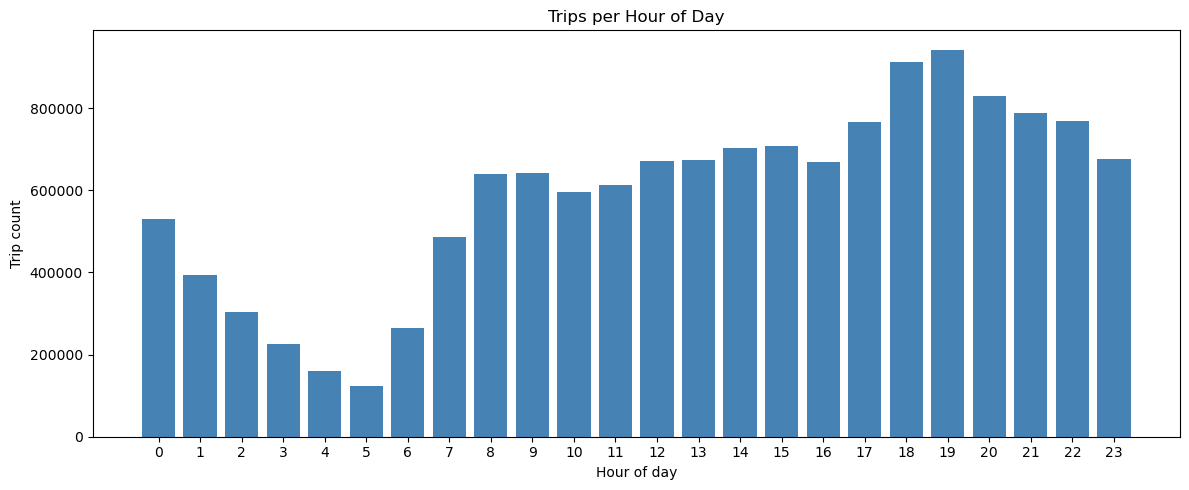

In [7]:
%matplotlib inline

import matplotlib.pyplot as plt
from pyspark.sql import functions as F

try:
    hourly_pdf = (
        df.withColumn("pickup_ts", F.col("Trip_Pickup_DateTime").cast("timestamp"))
          .withColumn("hour", F.hour("pickup_ts"))
          .groupBy("hour")
          .count()
          .orderBy("hour")
          .toPandas()
    )

    hourly_pdf = (
        hourly_pdf
        .set_index("hour")
        .reindex(range(24), fill_value=0)
        .reset_index()
    )

    plt.figure(figsize=(12, 5))
    plt.bar(hourly_pdf["hour"], hourly_pdf["count"], color="steelblue")
    plt.title("Trips per Hour of Day")
    plt.xlabel("Hour of day")
    plt.ylabel("Trip count")
    plt.xticks(range(24))
    plt.tight_layout()
    plt.show()

except Exception as e:
    print("Could not create hourly plot")
    print(e)


- Vemos como las horas con mas demanda de viajes comprende la franja de 17-23. Con clara alfuencia continua de viajes durante las horas de la mañana y con una caida acusada en horas de madrugada

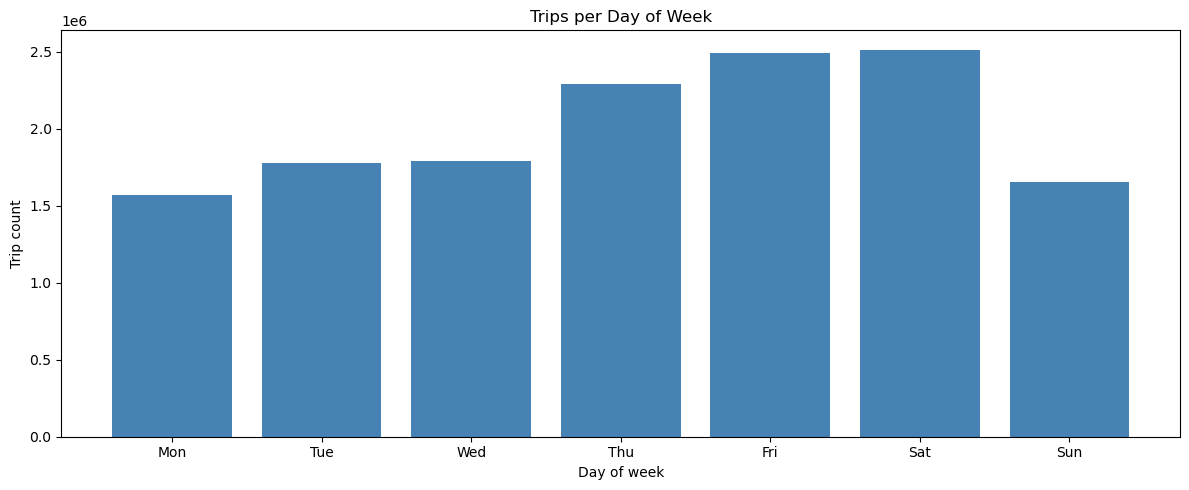

In [8]:
%matplotlib inline

import pandas as pd
import matplotlib.pyplot as plt
from pyspark.sql import functions as F

try:
    dow_pdf = (
        df.withColumn("pickup_ts", F.col("Trip_Pickup_DateTime").cast("timestamp"))
          .withColumn("dow_spark", F.dayofweek("pickup_ts"))
          .groupBy("dow_spark")
          .count()
          .toPandas()
    )
    dow_order = pd.DataFrame({"dow_spark": [2, 3, 4, 5, 6, 7, 1], "day": ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]})
    dow_plot_pdf = dow_order.merge(dow_pdf, on="dow_spark", how="left").fillna({"count": 0})

    plt.figure(figsize=(12, 5))
    plt.bar(dow_plot_pdf["day"], dow_plot_pdf["count"], color="steelblue")
    plt.title("Trips per Day of Week")
    plt.xlabel("Day of week")
    plt.ylabel("Trip count")
    plt.tight_layout()
    plt.show()
except Exception:
    print("Column tpep_pickup_datetime not found, skipping")


- Tanto viernes como sabado son los dias con mas viajes en NY en taxi

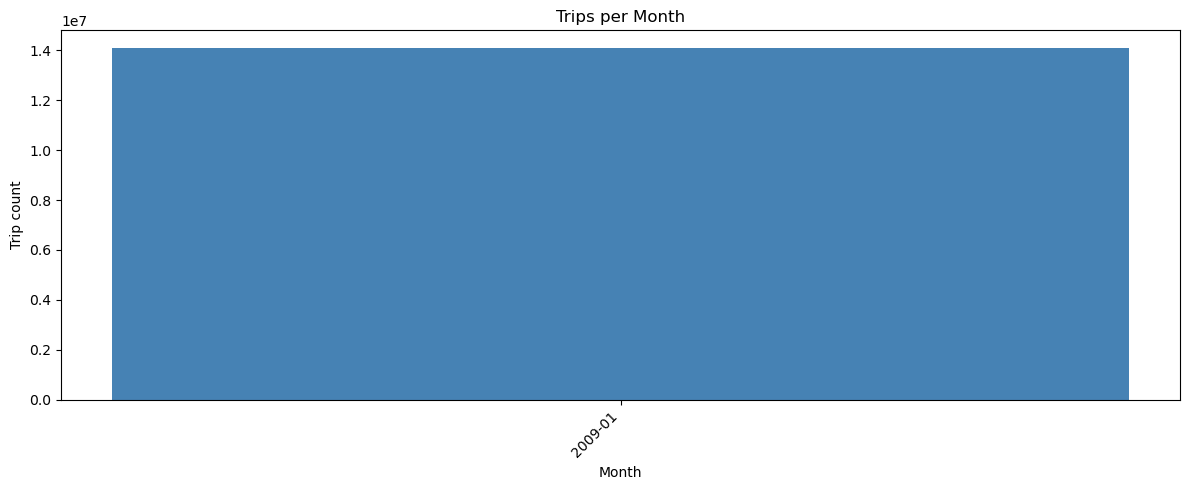

In [9]:
%matplotlib inline

import matplotlib.pyplot as plt
from pyspark.sql import functions as F

try:
    month_pdf = (
        df.withColumn("pickup_ts", F.col("Trip_Pickup_DateTime").cast("timestamp"))
          .withColumn("pickup_month", F.date_format("pickup_ts", "yyyy-MM"))
          .groupBy("pickup_month")
          .count()
          .orderBy("pickup_month")
          .toPandas()
    )

    plt.figure(figsize=(12, 5))
    plt.bar(month_pdf["pickup_month"], month_pdf["count"], color="steelblue")
    plt.title("Trips per Month")
    plt.xlabel("Month")
    plt.ylabel("Trip count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
except Exception:
    print("Column tpep_pickup_datetime not found, skipping")


- De momento solo hemos tomado los viajes de enero de 2009 por lo que el 100% son en enero

In [10]:
%matplotlib inline

import matplotlib.pyplot as plt
from pyspark.sql import functions as F

try:
    year_pdf = (
        df.withColumn("pickup_ts", F.col("Trip_Pickup_DateTime").cast("timestamp"))
          .withColumn("pickup_year", F.year("pickup_ts"))
          .groupBy("pickup_year")
          .count()
          .orderBy("pickup_year")
          .toPandas()
    )
    if len(year_pdf) > 1:
        plt.figure(figsize=(12, 5))
        plt.bar(year_pdf["pickup_year"].astype(str), year_pdf["count"], color="steelblue")
        plt.title("Trips per Year")
        plt.xlabel("Year")
        plt.ylabel("Trip count")
        plt.tight_layout()
        plt.show()
    else:
        print("Data does not span multiple years, skipping year plot")
except Exception:
    print("Column tpep_pickup_datetime not found, skipping")


Data does not span multiple years, skipping year plot


- De momento no tenemos varios años

## SECCIÓN 3 — CARACTERÍSTICAS DEL VIAJE
Exploración de distancia, duración, tarifa, velocidad y relación entre distancia y tarifa.

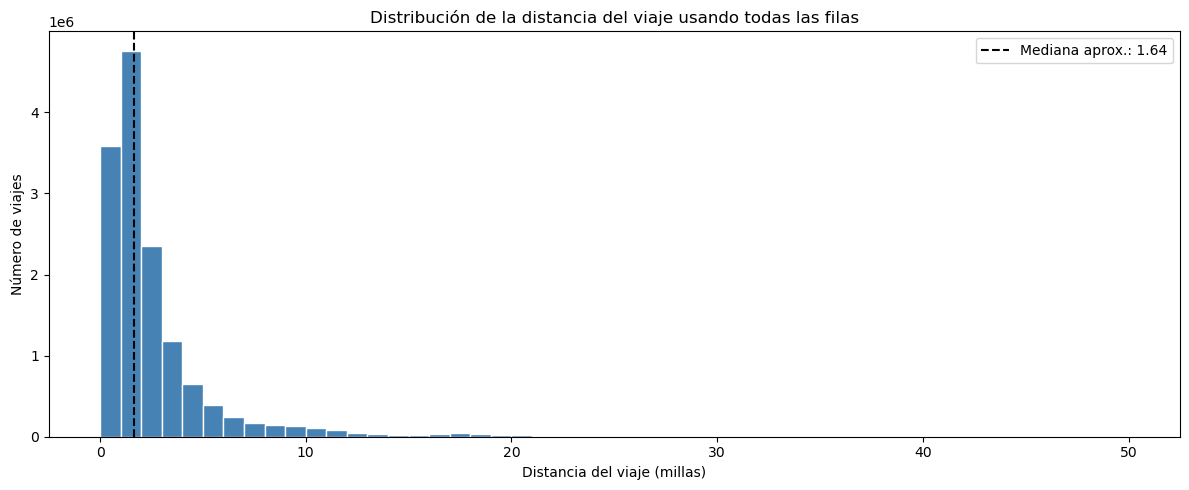

In [11]:
%matplotlib inline

import matplotlib.pyplot as plt
from pyspark.sql import functions as F

if "Trip_Distance" not in df.columns:
    print("Column Trip_Distance not found, skipping")
else:
    distance_df = (
        df.select(F.col("Trip_Distance").cast("double").alias("Trip_Distance"))
          .dropna()
          .filter(F.col("Trip_Distance") >= 0)
    )

    distance_p99 = distance_df.approxQuantile("Trip_Distance", [0.99], 0.01)[0]

    n_bins = 50
    bin_width = distance_p99 / n_bins

    distance_bins_pdf = (
        distance_df
        .filter(F.col("Trip_Distance") <= distance_p99)
        .withColumn(
            "bin",
            F.floor(F.col("Trip_Distance") / bin_width)
        )
        .filter((F.col("bin") >= 0) & (F.col("bin") < n_bins))
        .groupBy("bin")
        .count()
        .orderBy("bin")
        .toPandas()
    )

    distance_bins_pdf["bin_start"] = distance_bins_pdf["bin"] * bin_width
    distance_bins_pdf["bin_center"] = distance_bins_pdf["bin_start"] + bin_width / 2

    distance_median = distance_df.approxQuantile("Trip_Distance", [0.5], 0.01)[0]

    plt.figure(figsize=(12, 5))
    plt.bar(
        distance_bins_pdf["bin_center"],
        distance_bins_pdf["count"],
        width=bin_width,
        color="steelblue",
        edgecolor="white"
    )
    plt.axvline(
        distance_median,
        color="black",
        linestyle="--",
        label=f"Mediana aprox.: {distance_median:.2f}"
    )

    plt.title("Distribución de la distancia del viaje usando todas las filas")
    plt.xlabel("Distancia del viaje (millas)")
    plt.ylabel("Número de viajes")
    plt.legend()
    plt.tight_layout()
    plt.show()


- Vemos que la distancia mediana aproximadamente es de 1.64 millas. Sabemos que 1 milla = 1.6093 kilometros por lo que el viaje mediano oscila los 2.6 kilometros

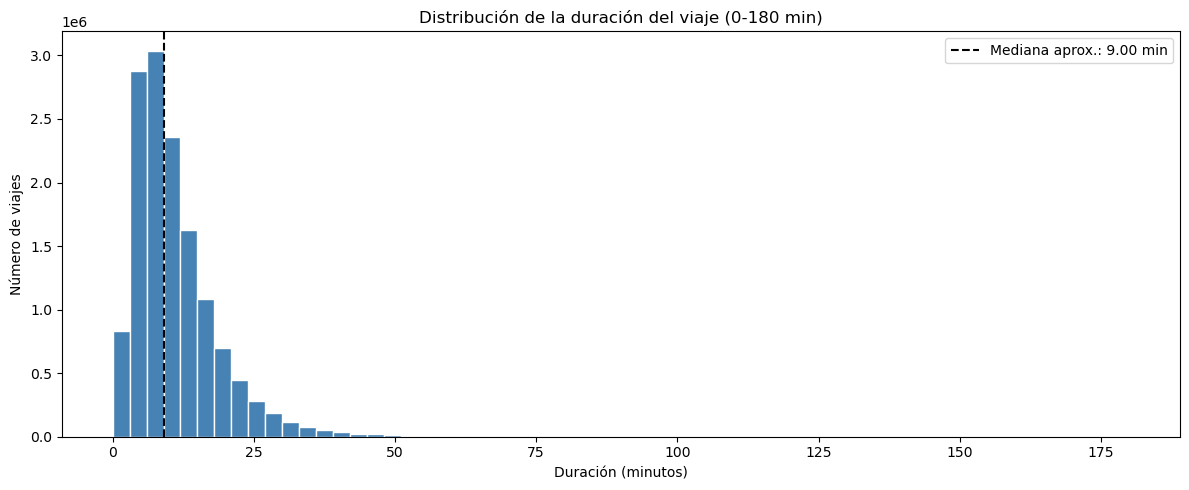

In [12]:
%matplotlib inline

import matplotlib.pyplot as plt
from pyspark.sql import functions as F

required_cols = ["Trip_Pickup_DateTime", "Trip_Dropoff_DateTime"]

missing_cols = [c for c in required_cols if c not in df.columns]

if missing_cols:
    print(f"Columns {missing_cols} not found, skipping")
else:
    duration_df = (
        df.withColumn("pickup_ts", F.col("Trip_Pickup_DateTime").cast("timestamp"))
          .withColumn("dropoff_ts", F.col("Trip_Dropoff_DateTime").cast("timestamp"))
          .withColumn(
              "duration_minutes",
              (F.unix_timestamp("dropoff_ts") - F.unix_timestamp("pickup_ts")) / 60.0
          )
          .select("duration_minutes")
          .dropna()
          .filter((F.col("duration_minutes") > 0) & (F.col("duration_minutes") <= 180))
    )

    duration_median = duration_df.approxQuantile("duration_minutes", [0.5], 0.01)[0]

    n_bins = 60
    max_duration = 180
    bin_width = max_duration / n_bins

    duration_bins_pdf = (
        duration_df
        .withColumn("bin", F.floor(F.col("duration_minutes") / bin_width))
        .filter((F.col("bin") >= 0) & (F.col("bin") < n_bins))
        .groupBy("bin")
        .count()
        .orderBy("bin")
        .toPandas()
    )

    duration_bins_pdf["bin_start"] = duration_bins_pdf["bin"] * bin_width
    duration_bins_pdf["bin_center"] = duration_bins_pdf["bin_start"] + bin_width / 2

    plt.figure(figsize=(12, 5))
    plt.bar(
        duration_bins_pdf["bin_center"],
        duration_bins_pdf["count"],
        width=bin_width,
        color="steelblue",
        edgecolor="white"
    )
    plt.axvline(
        duration_median,
        color="black",
        linestyle="--",
        label=f"Mediana aprox.: {duration_median:.2f} min"
    )

    plt.title("Distribución de la duración del viaje (0-180 min)")
    plt.xlabel("Duración (minutos)")
    plt.ylabel("Número de viajes")
    plt.legend()
    plt.tight_layout()
    plt.show()



- Aqui observamos que los viajes medios rondan los 9 minutos en mediana

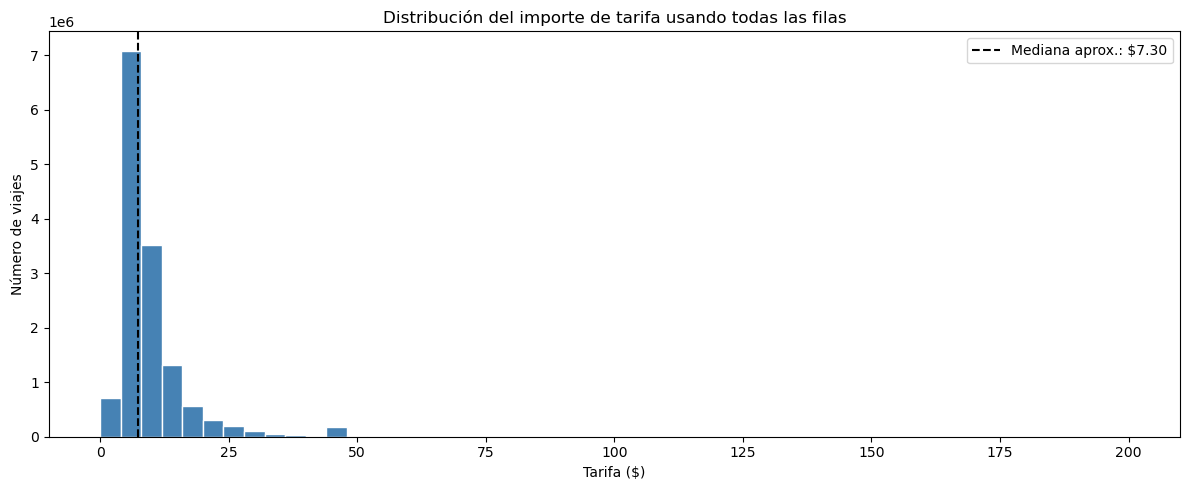

In [13]:
%matplotlib inline

import matplotlib.pyplot as plt
from pyspark.sql import functions as F

if "Fare_Amt" not in df.columns:
    print("Column Fare_Amt not found, skipping")
else:
    fare_df = (
        df.select(F.col("Fare_Amt").cast("double").alias("Fare_Amt"))
          .dropna()
          .filter(F.col("Fare_Amt") >= 0)
    )

    fare_p99 = fare_df.approxQuantile("Fare_Amt", [0.99], 0.01)[0]
    fare_median = fare_df.approxQuantile("Fare_Amt", [0.5], 0.01)[0]

    n_bins = 50
    bin_width = fare_p99 / n_bins

    fare_bins_pdf = (
        fare_df
        .filter(F.col("Fare_Amt") <= fare_p99)
        .withColumn("bin", F.floor(F.col("Fare_Amt") / bin_width))
        .filter((F.col("bin") >= 0) & (F.col("bin") < n_bins))
        .groupBy("bin")
        .count()
        .orderBy("bin")
        .toPandas()
    )

    fare_bins_pdf["bin_start"] = fare_bins_pdf["bin"] * bin_width
    fare_bins_pdf["bin_center"] = fare_bins_pdf["bin_start"] + bin_width / 2

    plt.figure(figsize=(12, 5))
    plt.bar(
        fare_bins_pdf["bin_center"],
        fare_bins_pdf["count"],
        width=bin_width,
        color="steelblue",
        edgecolor="white"
    )
    plt.axvline(
        fare_median,
        color="black",
        linestyle="--",
        label=f"Mediana aprox.: ${fare_median:.2f}"
    )

    plt.title("Distribución del importe de tarifa usando todas las filas")
    plt.xlabel("Tarifa ($)")
    plt.ylabel("Número de viajes")
    plt.legend()
    plt.tight_layout()
    plt.show()


- En mediana los viajes cuestan algo mas de 7 dolares

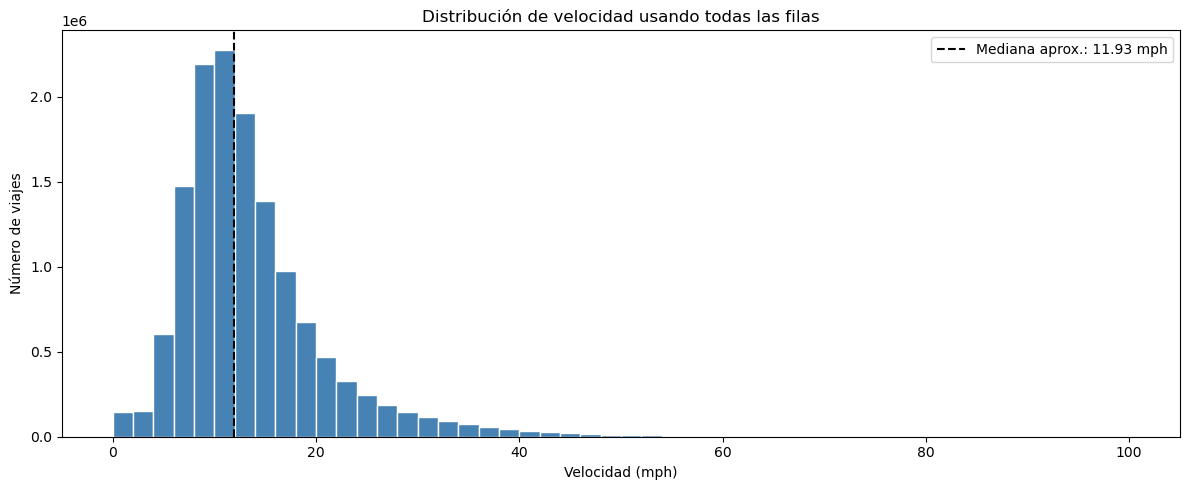

In [16]:
%matplotlib inline

import matplotlib.pyplot as plt
from pyspark.sql import functions as F

required_cols = ["Trip_Pickup_DateTime", "Trip_Dropoff_DateTime", "Trip_Distance"]

missing_cols = [c for c in required_cols if c not in df.columns]

if missing_cols:
    print(f"Columns {missing_cols} not found, skipping")
else:
    speed_df = (
        df.withColumn("pickup_ts", F.col("Trip_Pickup_DateTime").cast("timestamp"))
          .withColumn("dropoff_ts", F.col("Trip_Dropoff_DateTime").cast("timestamp"))
          .withColumn(
              "duration_hours",
              (F.unix_timestamp("dropoff_ts") - F.unix_timestamp("pickup_ts")) / 3600.0
          )
          .withColumn(
              "speed_mph",
              F.col("Trip_Distance").cast("double") / F.col("duration_hours")
          )
          .select("speed_mph")
          .dropna()
          .filter((F.col("speed_mph") > 0) & (F.col("speed_mph") <= 100))
    )

    n_bins = 50
    max_speed = 100
    bin_width = max_speed / n_bins

    speed_bins_pdf = (
        speed_df
        .withColumn("bin", F.floor(F.col("speed_mph") / bin_width))
        .filter((F.col("bin") >= 0) & (F.col("bin") < n_bins))
        .groupBy("bin")
        .count()
        .orderBy("bin")
        .toPandas()
    )

    speed_bins_pdf["bin_start"] = speed_bins_pdf["bin"] * bin_width
    speed_bins_pdf["bin_center"] = speed_bins_pdf["bin_start"] + bin_width / 2

    speed_median = speed_df.approxQuantile("speed_mph", [0.5], 0.01)[0]

    plt.figure(figsize=(12, 5))
    plt.bar(
        speed_bins_pdf["bin_center"],
        speed_bins_pdf["count"],
        width=bin_width,
        color="steelblue",
        edgecolor="white"
    )
    plt.axvline(
        speed_median,
        color="black",
        linestyle="--",
        label=f"Mediana aprox.: {speed_median:.2f} mph"
    )

    plt.title("Distribución de velocidad usando todas las filas")
    plt.xlabel("Velocidad (mph)")
    plt.ylabel("Número de viajes")
    plt.legend()
    plt.tight_layout()
    plt.show()


- La velocidad mediana es de unos 12 mph que equivale a casi 20 kmh

## SECCIÓN 4 — PASAJEROS Y PAGO
Revisión del número de pasajeros, métodos de pago, propinas y comportamiento de propinas por hora.

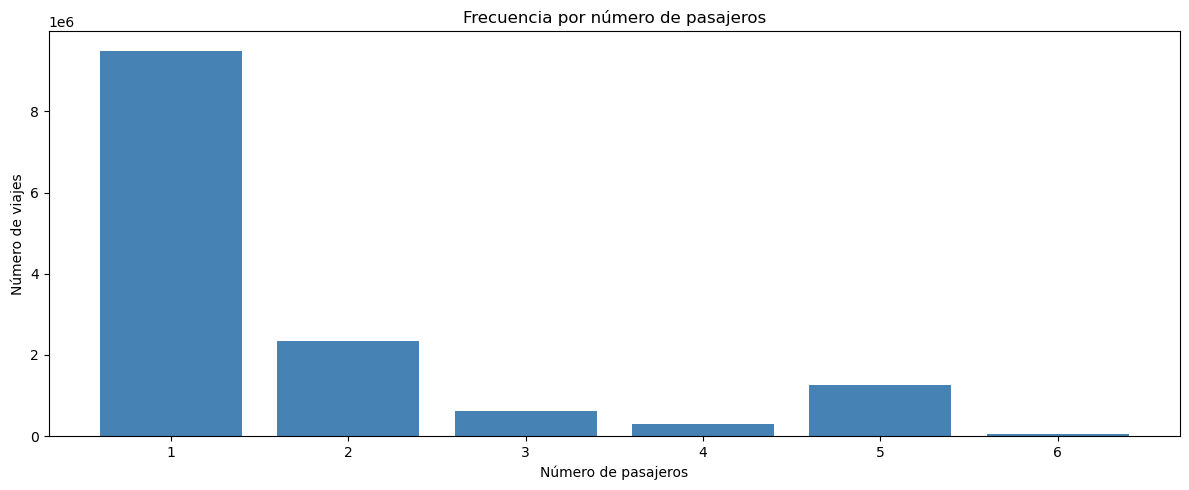

In [17]:
%matplotlib inline

import matplotlib.pyplot as plt
from pyspark.sql import functions as F

try:
    passenger_pdf = (
        df.select(F.col("Passenger_Count").cast("int").alias("Passenger_Count"))
          .dropna()
          .filter((F.col("Passenger_Count") > 0) & (F.col("Passenger_Count") <= 6))
          .groupBy("Passenger_Count")
          .count()
          .orderBy("Passenger_Count")
          .toPandas()
    )

    plt.figure(figsize=(12, 5))
    plt.bar(passenger_pdf["Passenger_Count"].astype(str), passenger_pdf["count"], color="steelblue")
    plt.title("Frecuencia por número de pasajeros")
    plt.xlabel("Número de pasajeros")
    plt.ylabel("Número de viajes")
    plt.tight_layout()
    plt.show()
except Exception as e:
    print("Column Passenger_Count not found, skipping")
    print(e)


- Lo mas habitual son viajes de 1,2 o 5 pasajeros

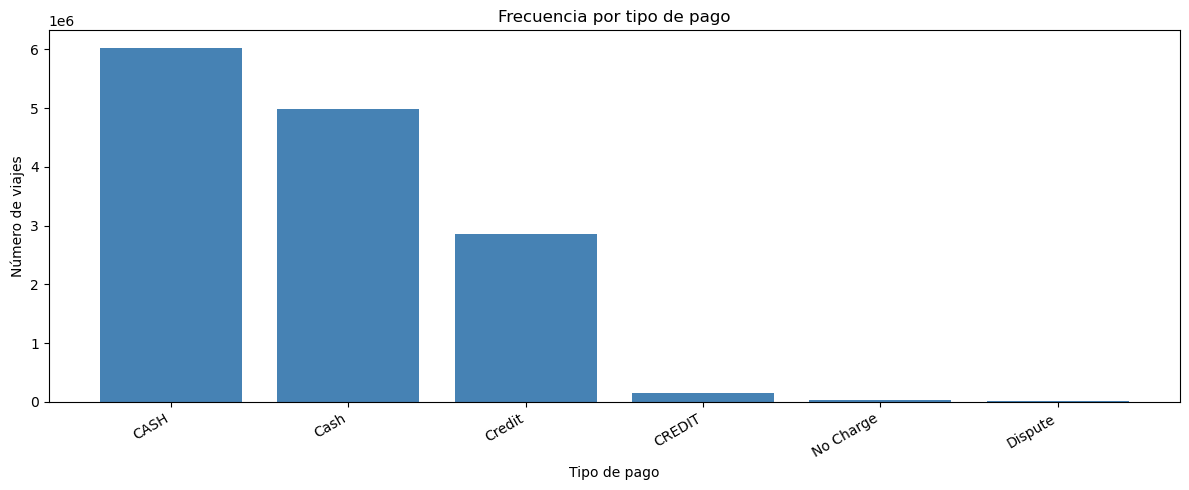

In [18]:
%matplotlib inline

import matplotlib.pyplot as plt
from pyspark.sql import functions as F

try:
    payment_pdf = (
        df.select(F.col("Payment_Type").cast("string").alias("Payment_Type"))
          .dropna()
          .groupBy("Payment_Type")
          .count()
          .orderBy(F.desc("count"))
          .toPandas()
    )

    plt.figure(figsize=(12, 5))
    plt.bar(payment_pdf["Payment_Type"], payment_pdf["count"], color="steelblue")
    plt.title("Frecuencia por tipo de pago")
    plt.xlabel("Tipo de pago")
    plt.ylabel("Número de viajes")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()
except Exception as e:
    print("Column Payment_Type not found, skipping")
    print(e)


- Observamos que lo mas comun en NYC en 2009 en el mes de enero era pagar en efectivo. Aqui hay un problema de redundancia de nombres, que podremos solucionar mas adelante en caso de que usemos estas columnas

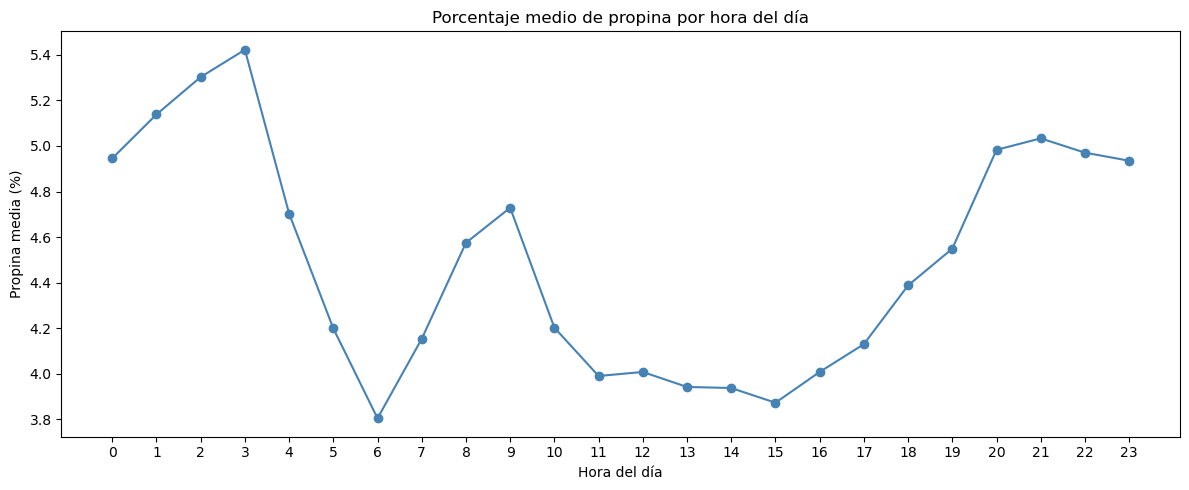

In [20]:
%matplotlib inline

import matplotlib.pyplot as plt
from pyspark.sql import functions as F

try:
    tip_pct_pdf = (
        df.withColumn("pickup_ts", F.col("Trip_Pickup_DateTime").cast("timestamp"))
          .withColumn("hour", F.hour("pickup_ts"))
          .withColumn("fare_amt_d", F.col("Fare_Amt").cast("double"))
          .withColumn("tip_amt_d", F.col("Tip_Amt").cast("double"))
          .filter(F.col("fare_amt_d") > 0)
          .withColumn("tip_pct", F.col("tip_amt_d") / F.col("fare_amt_d") * 100)
          .groupBy("hour")
          .agg(F.avg("tip_pct").alias("avg_tip_pct"))
          .orderBy("hour")
          .toPandas()
    )

    plt.figure(figsize=(12, 5))
    plt.plot(tip_pct_pdf["hour"], tip_pct_pdf["avg_tip_pct"], marker="o", color="steelblue")
    plt.title("Porcentaje medio de propina por hora del día")
    plt.xlabel("Hora del día")
    plt.ylabel("Propina media (%)")
    plt.xticks(range(24))
    plt.tight_layout()
    plt.show()
except Exception as e:
    print("Column Tip_Amt not found, skipping")
    print(e)


- Es curioso observar como las horas con menos propina son las del mediodia, y el pico de las mismas de 00 - 03 de la madrugada

## SECCIÓN 5 — ANÁLISIS GEOGRÁFICO
Análisis de coordenadas de recogida y destino disponibles en el dataset.

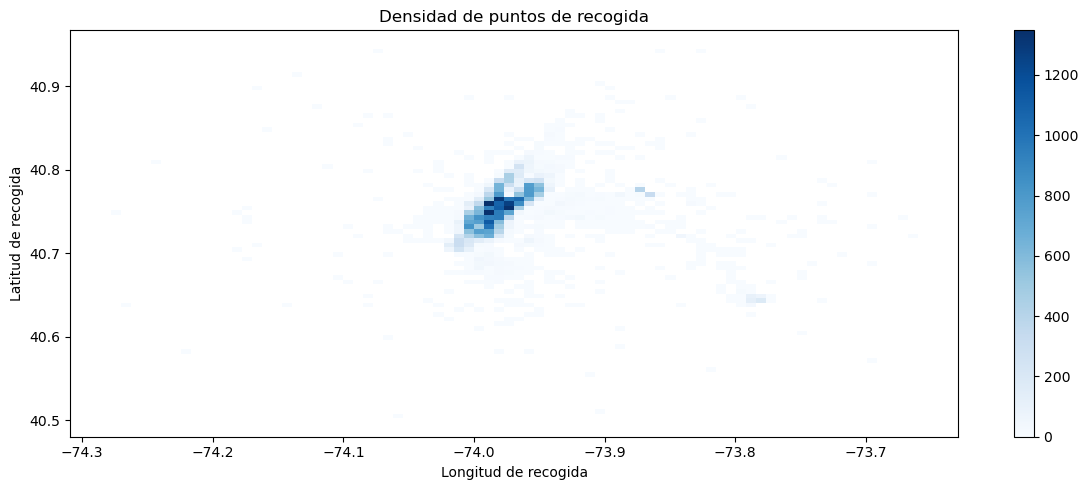

In [22]:
%matplotlib inline

import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import functions as F

try:
    pickup_pdf = (
        df.select(
              F.col("Start_Lon").cast("double").alias("Start_Lon"),
              F.col("Start_Lat").cast("double").alias("Start_Lat")
          )
          .dropna()
          .filter((F.col("Start_Lat").between(40.45, 40.95)) & (F.col("Start_Lon").between(-74.30, -73.65)))
          .sample(False, 0.01, seed=42)
          .limit(50000)
          .toPandas()
    )

    plt.figure(figsize=(12, 5))
    sns.histplot(data=pickup_pdf, x="Start_Lon", y="Start_Lat", bins=80, cmap="Blues", cbar=True)
    plt.title("Densidad de puntos de recogida")
    plt.xlabel("Longitud de recogida")
    plt.ylabel("Latitud de recogida")
    plt.tight_layout()
    plt.show()
except Exception as e:
    print("Column Start_Lon not found, skipping")
    print(e)


- Conclusiones mas adelante con el mapa global

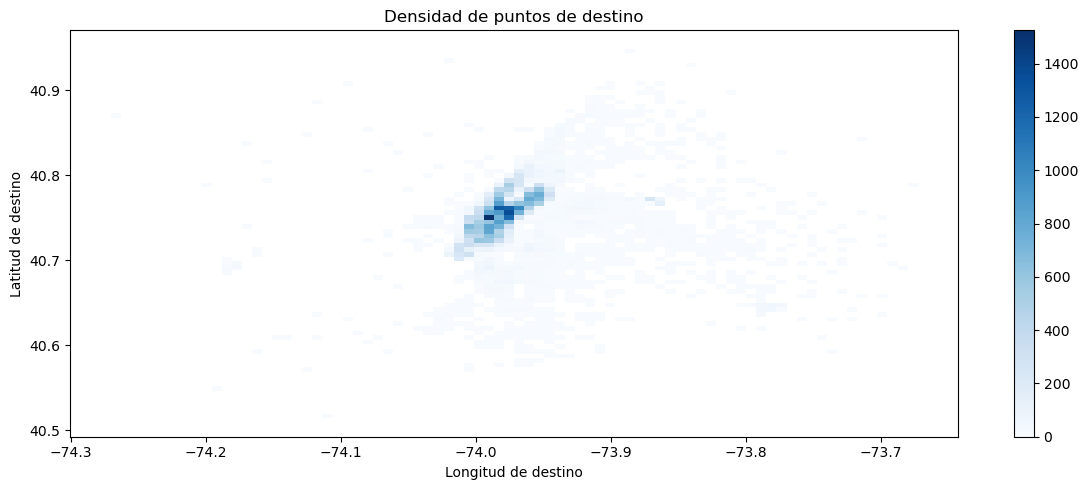

In [23]:
%matplotlib inline

import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import functions as F

try:
    dropoff_pdf = (
        df.select(
              F.col("End_Lon").cast("double").alias("End_Lon"),
              F.col("End_Lat").cast("double").alias("End_Lat")
          )
          .dropna()
          .filter((F.col("End_Lat").between(40.45, 40.95)) & (F.col("End_Lon").between(-74.30, -73.65)))
          .sample(False, 0.01, seed=42)
          .limit(50000)
          .toPandas()
    )

    plt.figure(figsize=(12, 5))
    sns.histplot(data=dropoff_pdf, x="End_Lon", y="End_Lat", bins=80, cmap="Blues", cbar=True)
    plt.title("Densidad de puntos de destino")
    plt.xlabel("Longitud de destino")
    plt.ylabel("Latitud de destino")
    plt.tight_layout()
    plt.show()
except Exception as e:
    print("Column End_Lon not found, skipping")
    print(e)


- Conclusiones mas adelante con el mapa global

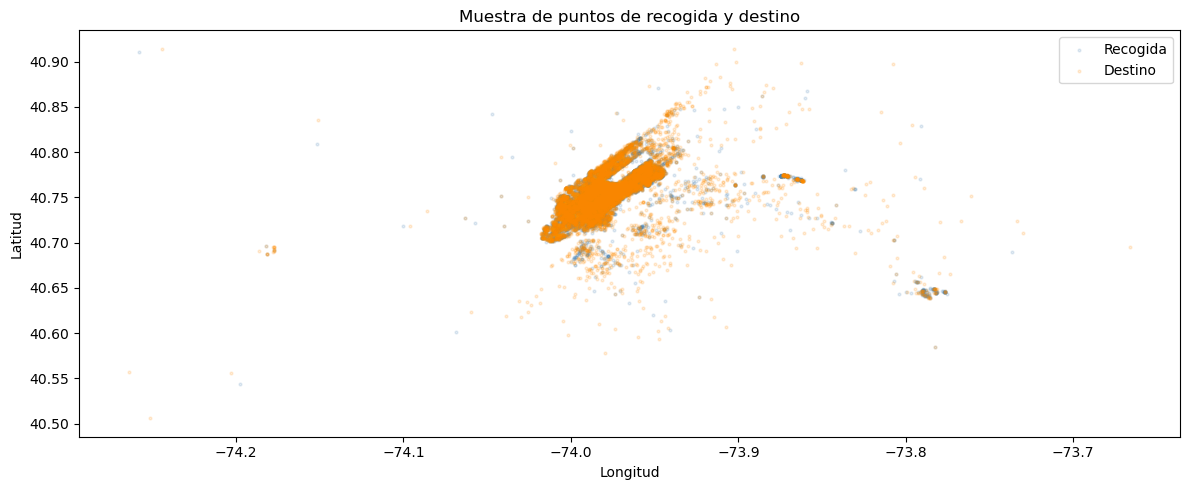

In [24]:
%matplotlib inline

import matplotlib.pyplot as plt
from pyspark.sql import functions as F

try:
    geo_sample_pdf = (
        df.select(
              F.col("Start_Lon").cast("double").alias("Start_Lon"),
              F.col("Start_Lat").cast("double").alias("Start_Lat"),
              F.col("End_Lon").cast("double").alias("End_Lon"),
              F.col("End_Lat").cast("double").alias("End_Lat")
          )
          .dropna()
          .filter(
              (F.col("Start_Lat").between(40.45, 40.95)) &
              (F.col("Start_Lon").between(-74.30, -73.65)) &
              (F.col("End_Lat").between(40.45, 40.95)) &
              (F.col("End_Lon").between(-74.30, -73.65))
          )
          .sample(False, 0.01, seed=42)
          .limit(10000)
          .toPandas()
    )

    plt.figure(figsize=(12, 5))
    plt.scatter(geo_sample_pdf["Start_Lon"], geo_sample_pdf["Start_Lat"], s=4, alpha=0.15, label="Recogida", color="steelblue")
    plt.scatter(geo_sample_pdf["End_Lon"], geo_sample_pdf["End_Lat"], s=4, alpha=0.15, label="Destino", color="darkorange")
    plt.title("Muestra de puntos de recogida y destino")
    plt.xlabel("Longitud")
    plt.ylabel("Latitud")
    plt.legend()
    plt.tight_layout()
    plt.show()
except Exception as e:
    print("Column Start_Lon not found, skipping")
    print(e)


- Conclusiones mas adelante con el mapa global

## SECCIÓN 6 — VISUALIZACIÓN EN MAPA
Visualización interactiva de todos los puntos de recogida válidos dentro del área de NYC.

In [8]:
import os
import folium
from folium.plugins import FastMarkerCluster
from IPython.display import display
import pyspark.sql.functions as F

# ============================================================
# 1. Preparar coordenadas de recogida
# ============================================================

coord_df = (
    df.select(
        F.col("Start_Lat").cast("double").alias("latitude"),
        F.col("Start_Lon").cast("double").alias("longitude")
    )
    .dropna()
    .filter(
        (F.col("latitude").between(40.45, 40.95)) &
        (F.col("longitude").between(-74.30, -73.65))
    )
    .sample(False, 0.01, seed=42)
    .limit(30000)
)

points_data = [
    [row.latitude, row.longitude]
    for row in coord_df.toLocalIterator()
]

# ============================================================
# 2. Crear mapa centrado en Nueva York
# ============================================================

pickup_map = folium.Map(
    location=[40.7128, -74.0060],
    zoom_start=11,
    tiles="cartodbpositron"
)

# ============================================================
# 3. Icono personalizado de taxi
# ============================================================

taxi_icon_callback = """
function (row) {
    var taxiIcon = L.divIcon({
        html: '<div style="font-size:18px;line-height:18px;">&#128661;</div>',
        className: 'taxi-marker',
        iconSize: [24, 24],
        iconAnchor: [12, 12]
    });

    return L.marker(
        new L.LatLng(row[0], row[1]),
        {icon: taxiIcon}
    );
}
"""

FastMarkerCluster(
    points_data,
    callback=taxi_icon_callback
).add_to(pickup_map)

# ============================================================
# 4. Rectángulo del área filtrada
# ============================================================

folium.Rectangle(
    bounds=[[40.45, -74.30], [40.95, -73.65]],
    color="#f59e0b",
    weight=2,
    fill=False,
    tooltip="Área de recogidas NYC"
).add_to(pickup_map)

# ============================================================
# 5. Guardar y mostrar mapa
# ============================================================

map_path = "../docs/map_pickup_points.html"

# No es obligatorio si ya existe, pero evita error si no existe
os.makedirs(os.path.dirname(map_path), exist_ok=True)

pickup_map.save(map_path)

print(f"HTML generado en: {os.path.abspath(map_path)}")
print(f"Puntos mostrados: {len(points_data):,}")

display(pickup_map)

HTML generado en: /home/alumno/Desktop/bigdata-nyc-taxi/docs/map_pickup_points.html
Puntos mostrados: 30,000


Puntos representados: 13,846,814
Pixeles ocupados: 161,391 de 3,520,000
Maximo de viajes en un pixel: 21,929
PNG generado en ../docs/all_pickup_points_raster.png
HTML generado en ../docs/map_all_pickup_points_raster.html



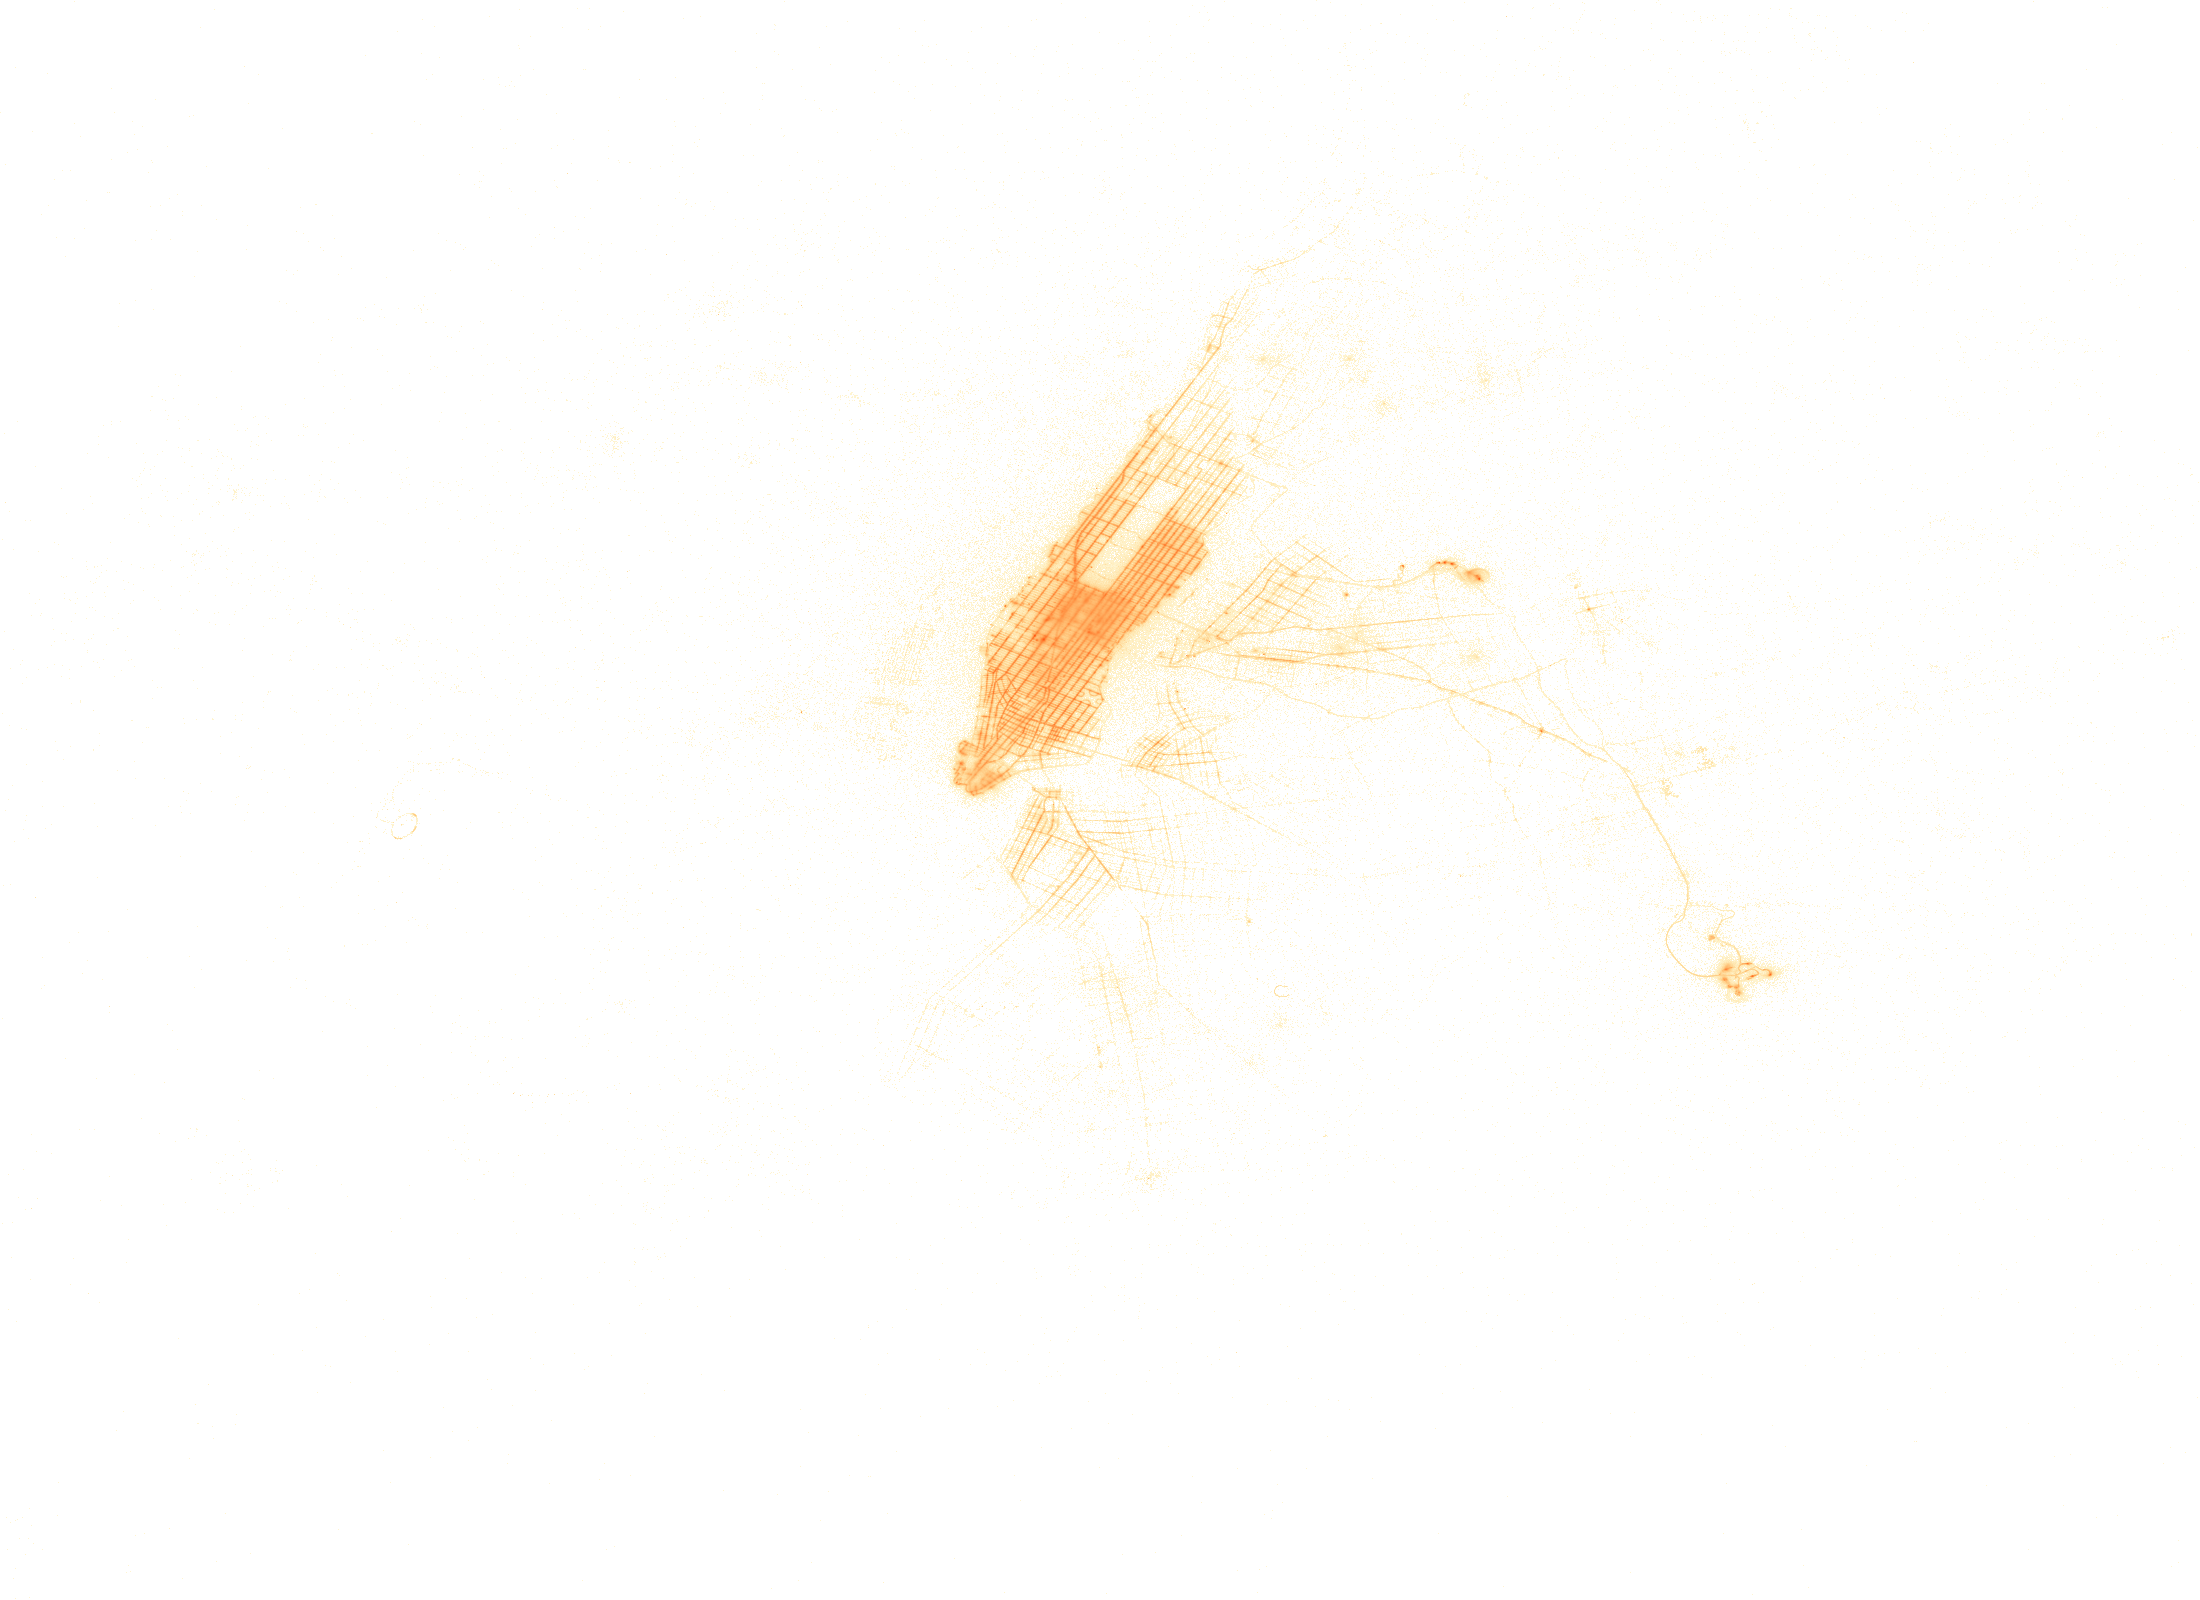

In [27]:
import math
import os

import folium
from folium.raster_layers import ImageOverlay
from IPython.display import display
from PIL import Image
from pyspark.sql import functions as F

# Representa todos los puntos de recogida como una capa raster.
# Cada viaje contribuye a un pixel; no se crean millones de marcadores HTML.
lat_min, lat_max = 40.45, 40.95
lon_min, lon_max = -74.30, -73.65
width, height = 2200, 1600

points_df = (
    df.select(
        F.col("Start_Lat").cast("double").alias("latitude"),
        F.col("Start_Lon").cast("double").alias("longitude")
    )
    .dropna()
    .filter(
        (F.col("latitude").between(lat_min, lat_max)) &
        (F.col("longitude").between(lon_min, lon_max))
    )
)

pixel_counts_df = (
    points_df
    .withColumn(
        "x",
        F.floor((F.col("longitude") - F.lit(lon_min)) / F.lit(lon_max - lon_min) * F.lit(width - 1)).cast("int")
    )
    .withColumn(
        "y",
        F.floor((F.lit(lat_max) - F.col("latitude")) / F.lit(lat_max - lat_min) * F.lit(height - 1)).cast("int")
    )
    .filter((F.col("x") >= 0) & (F.col("x") < width) & (F.col("y") >= 0) & (F.col("y") < height))
    .groupBy("x", "y")
    .count()
    .cache()
)

summary = pixel_counts_df.agg(
    F.sum("count").alias("total_points"),
    F.max("count").alias("max_pixel_count"),
    F.count("count").alias("occupied_pixels")
).first()

total_points = int(summary["total_points"] or 0)
max_pixel_count = int(summary["max_pixel_count"] or 1)
occupied_pixels = int(summary["occupied_pixels"] or 0)

img = Image.new("RGBA", (width, height), (0, 0, 0, 0))
pixels = img.load()
scale = math.log1p(max_pixel_count)

for row in pixel_counts_df.toLocalIterator():
    intensity = math.log1p(row["count"]) / scale if scale else 0
    alpha = int(35 + 220 * intensity)
    red = 255
    green = int(210 - 120 * intensity)
    blue = 20
    pixels[row["x"], row["y"]] = (red, green, blue, alpha)

os.makedirs("../docs", exist_ok=True)
image_path = "../docs/all_pickup_points_raster.png"
map_path = "../docs/map_all_pickup_points_raster.html"
img.save(image_path)

all_points_map = folium.Map(
    location=[39.8283, -98.5795],
    zoom_start=4,
    tiles="cartodbpositron"
)

ImageOverlay(
    image=image_path,
    bounds=[[lat_min, lon_min], [lat_max, lon_max]],
    opacity=0.75,
    interactive=True,
    cross_origin=False,
    zindex=1,
    name="Densidad de recogidas NYC",
).add_to(all_points_map)

folium.Rectangle(
    bounds=[[lat_min, lon_min], [lat_max, lon_max]],
    color="#1f2937",
    weight=2,
    fill=False,
    tooltip="Area NYC rasterizada con todos los puntos de recogida",
).add_to(all_points_map)

legend_html = f"""
<div style="
    position: fixed;
    bottom: 28px;
    left: 28px;
    z-index: 9999;
    width: 260px;
    padding: 12px 14px;
    background: rgba(255, 255, 255, 0.94);
    border: 1px solid #d1d5db;
    border-radius: 6px;
    box-shadow: 0 2px 8px rgba(0, 0, 0, 0.18);
    font-family: Arial, sans-serif;
    font-size: 12px;
    color: #111827;
">
    <div style="font-weight: 700; margin-bottom: 6px;">Recogidas de taxi</div>
    <div>Cada punto del dataset suma en un pixel de la capa naranja.</div>
    <div style="height: 10px; margin: 9px 0 5px 0; background: linear-gradient(to right, rgba(255,210,20,0.25), rgba(255,150,20,0.7), rgba(255,90,20,1));"></div>
    <div style="display: flex; justify-content: space-between; margin-bottom: 6px;">
        <span>Menos viajes</span><span>Mas viajes</span>
    </div>
    <div>Puntos: {total_points:,}</div>
    <div>Pixeles ocupados: {occupied_pixels:,}</div>
    <div>Maximo por pixel: {max_pixel_count:,}</div>
    <div style="margin-top: 6px; color: #4b5563;">El rectangulo marca el area NYC usada.</div>
</div>
"""
all_points_map.get_root().html.add_child(folium.Element(legend_html))

folium.LayerControl().add_to(all_points_map)
all_points_map.save(map_path)

print(f"Puntos representados: {total_points:,}")
print(f"Pixeles ocupados: {occupied_pixels:,} de {width * height:,}")
print(f"Maximo de viajes en un pixel: {max_pixel_count:,}")
print(f"PNG generado en {image_path}")
print(f"HTML generado en {map_path}")

display(all_points_map)


- En ambos graficos osbervamos como la mayoria de viajes se concentran en manhattan